In [1]:
from __future__ import annotations

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt


def build_env(map_name: str = "8x8", slippery: bool = True):
	return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=slippery)


def extract_model(env: gym.Env):
	n_states = env.observation_space.n
	n_actions = env.action_space.n
	transition = np.zeros((n_states, n_actions, n_states), dtype=float)
	reward = np.zeros((n_states, n_actions, n_states), dtype=float)

	for state in range(n_states):
		for action in range(n_actions):
			for prob, next_state, r, _terminated in env.unwrapped.P[state][action]:
				transition[state, action, next_state] += prob
				reward[state, action, next_state] = r

	expected_reward = np.sum(transition * reward, axis=2)
	return transition, reward, expected_reward


def q_values(transition, expected_reward, values, gamma):
	future = np.einsum("sat,t->sa", transition, values)
	return expected_reward + gamma * future


def policy_evaluation_matrix(transition, expected_reward, policy, gamma=0.99):
	n_states = transition.shape[0]
	rows = np.arange(n_states)
	policy_transition = transition[rows, policy]
	policy_reward = expected_reward[rows, policy]
	system = np.eye(n_states) - gamma * policy_transition
	values = np.linalg.solve(system, policy_reward)
	return values

In [2]:
def policy_iteration(transition, expected_reward, gamma=0.99, max_iterations=1000):
	n_states = transition.shape[0]
	policy = np.zeros(n_states, dtype=int)

	for iteration in range(max_iterations):
		values = policy_evaluation_matrix(transition, expected_reward, policy, gamma)
		q = q_values(transition, expected_reward, values, gamma)
		new_policy = np.argmax(q, axis=1)
		if np.array_equal(new_policy, policy):
			return values, policy, iteration + 1
		policy = new_policy

	values = policy_evaluation_matrix(transition, expected_reward, policy, gamma)
	return values, policy, max_iterations

def generate_episode(env, policy, epsilon=0.0, max_steps=200):
	state, _ = env.reset()
	episode = []

	for _ in range(max_steps):
		if np.random.rand() < epsilon:
			action = env.action_space.sample()
		else:
			action = policy[state]

		next_state, reward, terminated, truncated, _ = env.step(action)
		episode.append((state, action, reward))
		state = next_state

		if terminated or truncated:
			break

	return episode

In [3]:
def monte_carlo_control_greedy(env, gamma=0.99, episodes=5000, max_steps=100):

    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q_sum = np.zeros((n_states, n_actions))
    Q_count = np.zeros((n_states, n_actions))

    policy = np.zeros(n_states, dtype=int)

    for _ in range(episodes):

        state, _ = env.reset()
        episode = []

        for _ in range(max_steps):

            action = policy[state]

            next_state, reward, terminated, truncated, _ = env.step(action)

            episode.append((state, action, reward))
            state = next_state

            if terminated or truncated:
                break

        G = 0
        visited = set()

        for t in reversed(range(len(episode))):

            s, a, r = episode[t]
            G = r + gamma * G

            if (s, a) not in visited:
                visited.add((s, a))

                Q_sum[s, a] += G
                Q_count[s, a] += 1

                Q = Q_sum / np.maximum(Q_count, 1e-8)

                policy[s] = np.argmax(Q[s])

    Q = Q_sum / np.maximum(Q_count, 1e-8)

    return Q, policy

In [4]:
def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()

In [5]:
def plot_metrics(rewards, lengths, title="Training"):
	plt.figure()
	plt.plot(rewards)
	plt.title(title + " - Rewards")
	plt.xlabel("Episode")
	plt.ylabel("Reward")
	plt.show()

	plt.figure()
	plt.plot(lengths)
	plt.title(title + " - Episode Length")
	plt.xlabel("Episode")
	plt.ylabel("Steps")
	plt.show()

FrozenLake-v1 8x8
states: 64, actions: 4
Legend: S=start, F=frozen, H=hole, G=goal

Policy Iteration Policy:
[1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 0 1 2 1 1 2 2 2 2 1 0 1 1 2 2 3 0 1
 1 2 1 1 0 0 2 2 1 0 1 1 0 2 3 0 1 0 1 2 2 3 0 2 2 2 0]


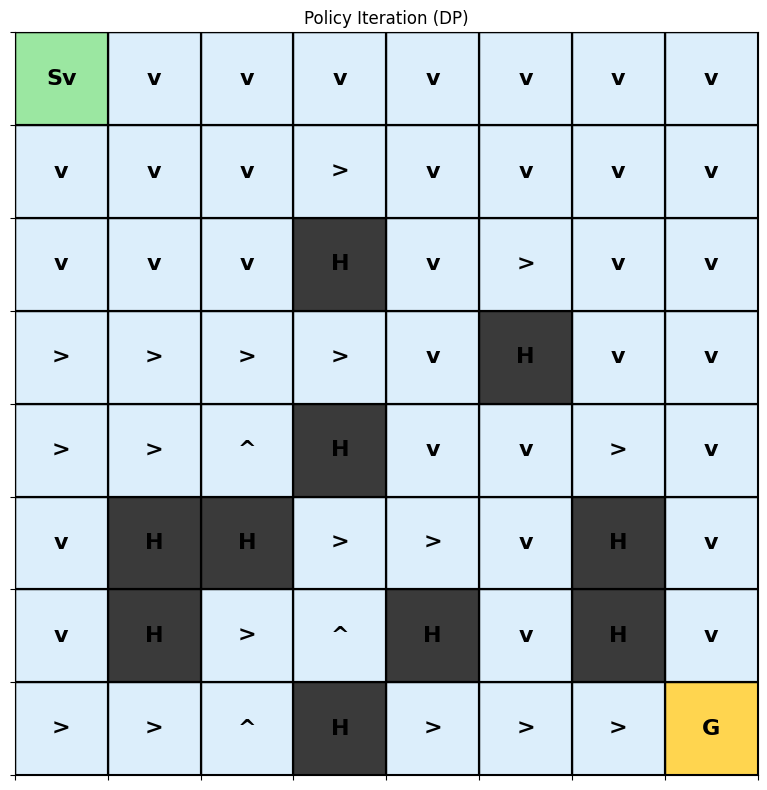


Monte Carlo Control Policy:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


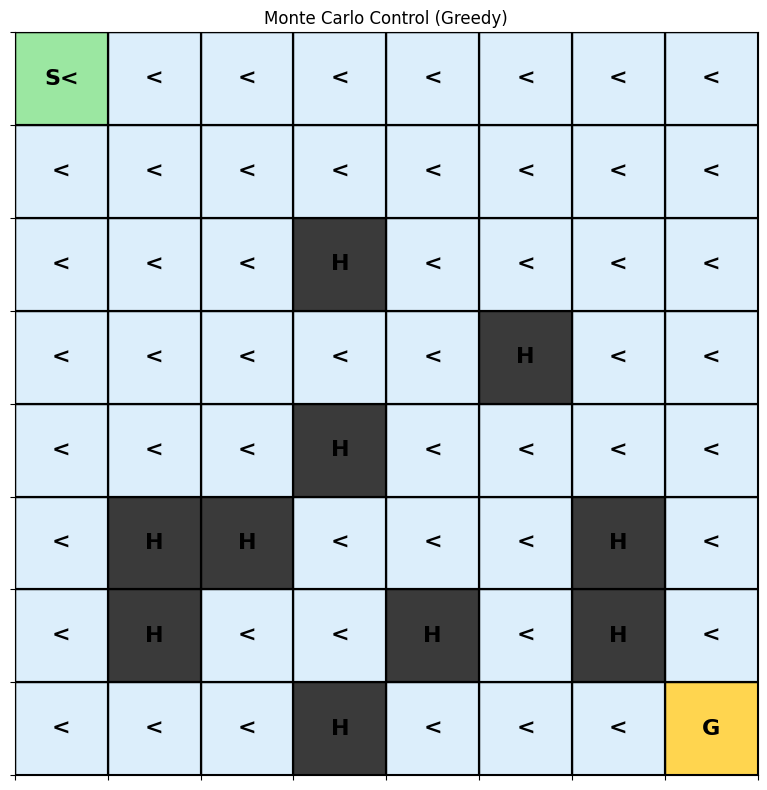

In [6]:
gamma = 0.99
env = build_env(slippery=False)

transition, reward, expected_reward = extract_model(env)

print("FrozenLake-v1 8x8")
print(f"states: {transition.shape[0]}, actions: {transition.shape[1]}")
print("Legend: S=start, F=frozen, H=hole, G=goal")

V, pi_policy, _ = policy_iteration(transition, expected_reward, gamma=gamma)

print("\nPolicy Iteration Policy:")
print(pi_policy)

plot_policy_on_frozen_lake(
    env,
    pi_policy,
    title="Policy Iteration (DP)"
)

Q_mc, mc_policy = monte_carlo_control_greedy(
    env,
    gamma=gamma,
    episodes=8000
)

print("\nMonte Carlo Control Policy:")
print(mc_policy)

plot_policy_on_frozen_lake(
    env,
    mc_policy,
    title="Monte Carlo Control (Greedy)"
)